# 01 — Datos Simulados: Movimientos Diarios de Tesorería

**Proyecto:** Skill Financiero — Agente de Tesorería  
**Autor:** Gabriel Untiveros  
**Fecha:** 2026-05-25

---

## Objetivo

Generar `movimientos_diarios.csv` con **90 días × 3 cuentas bancarias**:

| Cuenta | Banco | Moneda | Comportamiento |
|---|---|---|---|
| `CUENTA-001` | BCP | PEN | Operativa principal — flujo estable |
| `CUENTA-002` | BBVA | PEN | Planilla — picos quincenales |
| `CUENTA-003` | Interbank | USD | Dólares — flujo irregular |

**Campos:** `cuenta_id | fecha | saldo_cierre | ingresos_dia | egresos_dia | moneda`

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

np.random.seed(42)

FECHA_INICIO = pd.Timestamp('2026-02-24')
DIAS         = 90
fechas       = pd.date_range(FECHA_INICIO, periods=DIAS, freq='D')
OUTPUT_PATH  = Path('../data/movimientos_diarios.csv')
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f'Rango: {fechas[0].date()} -> {fechas[-1].date()} ({DIAS} dias)')

Rango: 2026-02-24 -> 2026-05-24 (90 dias)


---
## CUENTA-001 — Operativa Principal (PEN)
Ingresos ~18,000/dia, egresos ~15,000/dia. Periodo de estres simulado dias 60-70 (egresos x1.8).

In [2]:
saldo_inicial_c001 = 250_000.0

ingresos_c001 = np.random.normal(loc=18_000, scale=3_500, size=DIAS).clip(min=0)
egresos_c001  = np.random.normal(loc=15_000, scale=2_000, size=DIAS).clip(min=0)

# Periodo de estres: dias 60-70
egresos_c001[60:70] *= 1.8

saldo_c001 = saldo_inicial_c001 + np.cumsum(ingresos_c001 - egresos_c001)

df_c001 = pd.DataFrame({
    'cuenta_id'    : 'CUENTA-001',
    'fecha'        : fechas,
    'saldo_cierre' : np.round(saldo_c001, 2),
    'ingresos_dia' : np.round(ingresos_c001, 2),
    'egresos_dia'  : np.round(egresos_c001, 2),
    'moneda'       : 'PEN',
})

print(f'CUENTA-001 | min: S/ {saldo_c001.min():,.0f} | max: S/ {saldo_c001.max():,.0f} | final: S/ {saldo_c001[-1]:,.0f}')
df_c001.tail(3)

CUENTA-001 | min: S/ 254,544 | max: S/ 404,435 | final: S/ 356,608


,cuenta_id,fecha,saldo_cierre,ingresos_dia,egresos_dia,moneda
87,CUENTA-001,2026-05-22,355577.16,19150.63,17907.07,PEN
88,CUENTA-001,2026-05-23,357252.31,16145.84,14470.69,PEN
89,CUENTA-001,2026-05-24,356608.41,19796.44,20440.34,PEN


---
## CUENTA-002 — Planilla (PEN)
Egresos grandes los dias 15 y 30 (~38,000 planilla quincenal). Cuenta mas interesante para el skill de alertas.

In [3]:
saldo_inicial_c002 = 80_000.0

ingresos_c002 = np.random.normal(loc=3_000, scale=500, size=DIAS).clip(min=0)

# Fondeo un dia antes de la planilla (dias 14 y 29)
for i, fecha in enumerate(fechas):
    if fecha.day in (14, 29):
        ingresos_c002[i] += np.random.normal(40_000, 3_000)

egresos_c002 = np.random.normal(loc=1_500, scale=300, size=DIAS).clip(min=0)

# Planilla dias 15 y 30
for i, fecha in enumerate(fechas):
    if fecha.day in (15, 30):
        egresos_c002[i] += np.random.normal(38_000, 2_000)

saldo_c002 = saldo_inicial_c002 + np.cumsum(ingresos_c002 - egresos_c002)
saldo_c002 = np.maximum(saldo_c002, 1_000)

df_c002 = pd.DataFrame({
    'cuenta_id'    : 'CUENTA-002',
    'fecha'        : fechas,
    'saldo_cierre' : np.round(saldo_c002, 2),
    'ingresos_dia' : np.round(ingresos_c002, 2),
    'egresos_dia'  : np.round(egresos_c002, 2),
    'moneda'       : 'PEN',
})

print(f'CUENTA-002 | min: S/ {saldo_c002.min():,.0f} | max: S/ {saldo_c002.max():,.0f} | final: S/ {saldo_c002[-1]:,.0f}')
df_c002.tail(3)

CUENTA-002 | min: S/ 81,674 | max: S/ 249,581 | final: S/ 224,331


,cuenta_id,fecha,saldo_cierre,ingresos_dia,egresos_dia,moneda
87,CUENTA-002,2026-05-22,221812.99,2284.93,1467.37,PEN
88,CUENTA-002,2026-05-23,222972.46,2779.98,1620.51,PEN
89,CUENTA-002,2026-05-24,224330.79,3065.37,1707.04,PEN


---
## CUENTA-003 — Dolares (USD)
Pagos a proveedores importados. Flujo irregular: no todos los dias hay movimiento.

In [4]:
saldo_inicial_c003 = 15_000.0  # USD

# Ingresos esporadicos (50% dias sin ingreso)
ingresos_c003 = np.random.choice(
    [0, 0, 0, 2_000, 3_500, 5_000],
    size=DIAS, p=[0.2, 0.15, 0.15, 0.2, 0.2, 0.1]
).astype(float) + np.random.normal(0, 100, DIAS)
ingresos_c003 = ingresos_c003.clip(min=0)

# Egresos 2-3 veces por semana
egresos_c003 = np.random.choice(
    [0, 0, 0, 1_500, 2_500, 4_000],
    size=DIAS, p=[0.3, 0.2, 0.1, 0.2, 0.15, 0.05]
).astype(float).clip(min=0)

saldo_c003 = saldo_inicial_c003 + np.cumsum(ingresos_c003 - egresos_c003)
saldo_c003 = np.maximum(saldo_c003, 500)

df_c003 = pd.DataFrame({
    'cuenta_id'    : 'CUENTA-003',
    'fecha'        : fechas,
    'saldo_cierre' : np.round(saldo_c003, 2),
    'ingresos_dia' : np.round(ingresos_c003, 2),
    'egresos_dia'  : np.round(egresos_c003, 2),
    'moneda'       : 'USD',
})

print(f'CUENTA-003 | min: USD {saldo_c003.min():,.0f} | max: USD {saldo_c003.max():,.0f} | final: USD {saldo_c003[-1]:,.0f}')
df_c003.tail(3)

CUENTA-003 | min: USD 18,473 | max: USD 121,874 | final: USD 118,639


,cuenta_id,fecha,saldo_cierre,ingresos_dia,egresos_dia,moneda
87,CUENTA-003,2026-05-22,120085.08,2075.14,0.0,USD
88,CUENTA-003,2026-05-23,120085.08,0.00,0.0,USD
89,CUENTA-003,2026-05-24,118639.42,54.34,1500.0,USD


---
## Consolidar y exportar

In [5]:
df = pd.concat([df_c001, df_c002, df_c003], ignore_index=True)
df['fecha'] = df['fecha'].dt.strftime('%Y-%m-%d')
df = df.sort_values(['cuenta_id', 'fecha']).reset_index(drop=True)

print(f'Total registros: {len(df)} | Cuentas: {df["cuenta_id"].nunique()} | Dias por cuenta: {DIAS}')
print()
resumen = df.groupby(['cuenta_id', 'moneda']).agg(
    dias=("fecha", "count"),
    saldo_min=("saldo_cierre", "min"),
    saldo_max=("saldo_cierre", "max"),
    saldo_prom=("saldo_cierre", "mean")
).round(0)
print(resumen.to_string())

Total registros: 270 | Cuentas: 3 | Dias por cuenta: 90

                   dias  saldo_min  saldo_max  saldo_prom
cuenta_id  moneda                                        
CUENTA-001 PEN       90   254544.0   404435.0    333373.0
CUENTA-002 PEN       90    81674.0   249581.0    156546.0
CUENTA-003 USD       90    18473.0   121874.0     76441.0


In [6]:
df.to_csv(OUTPUT_PATH, index=False)
print(f'Exportado: {OUTPUT_PATH.resolve()}')
print(f'Tamano: {OUTPUT_PATH.stat().st_size / 1024:.1f} KB')
print()
df.head(6)

Exportado: D:\Proyecto_Gabriel\Skill_financiero\data\movimientos_diarios.csv
Tamano: 13.7 KB



,cuenta_id,fecha,saldo_cierre,ingresos_dia,egresos_dia,moneda
0,CUENTA-001,2026-02-24,254544.34,19738.50,15194.16,PEN
1,CUENTA-001,2026-02-25,255123.13,17516.07,16937.29,PEN
2,CUENTA-001,2026-02-26,261794.15,20266.91,13595.89,PEN
3,CUENTA-001,2026-02-27,270780.07,23330.60,14344.68,PEN
4,CUENTA-001,2026-02-28,273744.75,17180.46,14215.78,PEN
5,CUENTA-001,2026-03-01,278852.30,17180.52,12072.97,PEN


---
## Verificaciones automaticas

In [7]:
df_v = pd.read_csv(OUTPUT_PATH)

assert set(df_v['cuenta_id'].unique()) == {'CUENTA-001','CUENTA-002','CUENTA-003'}
assert (df_v.groupby('cuenta_id')['fecha'].count() == 90).all()
assert 'USD' in df_v['moneda'].values

c002 = df_v[df_v['cuenta_id'] == 'CUENTA-002']
assert c002['egresos_dia'].max() > 30_000, 'Sin picos de planilla'

c001 = df_v[df_v['cuenta_id'] == 'CUENTA-001'].reset_index(drop=True)
assert c001.loc[60:70, 'egresos_dia'].mean() > c001['egresos_dia'].mean() * 1.3, 'Sin periodo de estres'

print('OK: Todas las verificaciones pasaron')
print()
print('Egresos maximos por cuenta:')
print(df_v.groupby('cuenta_id')['egresos_dia'].max().apply(lambda x: f'{x:,.0f}'))

OK: Todas las verificaciones pasaron

Egresos maximos por cuenta:
cuenta_id
CUENTA-001    33,717
CUENTA-002    39,888
CUENTA-003     4,000
Name: egresos_dia, dtype: str


---
## Visualizacion — Evolucion de saldos

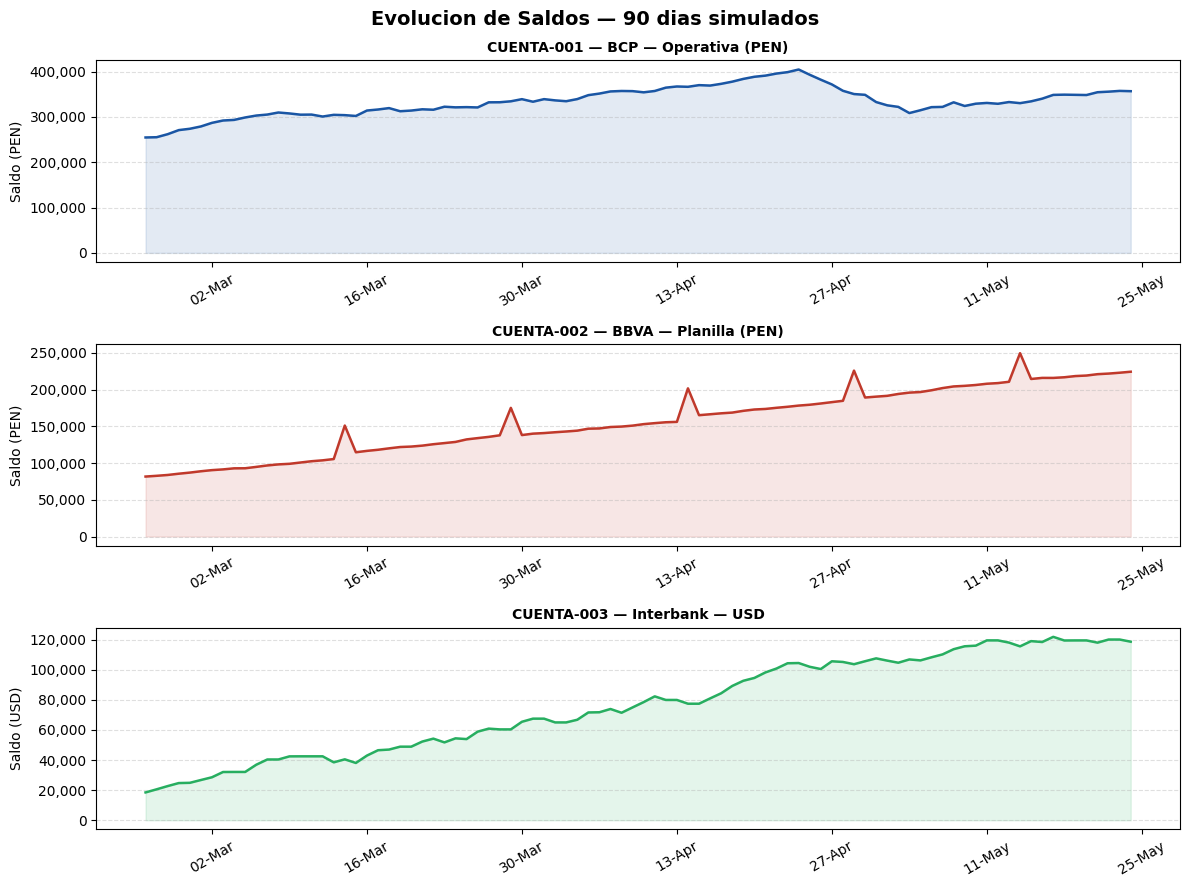

Grafico guardado en data/saldos_90dias.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_plot = pd.read_csv(OUTPUT_PATH, parse_dates=['fecha'])

cuentas = [
    ('CUENTA-001', 'BCP — Operativa (PEN)',  '#1a56a4'),
    ('CUENTA-002', 'BBVA — Planilla (PEN)',  '#c0392b'),
    ('CUENTA-003', 'Interbank — USD',        '#27ae60'),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)
fig.suptitle('Evolucion de Saldos — 90 dias simulados', fontsize=14, fontweight='bold')

for ax, (cid, titulo, color) in zip(axes, cuentas):
    sub = df_plot[df_plot['cuenta_id'] == cid]
    moneda = sub['moneda'].iloc[0]
    ax.plot(sub['fecha'], sub['saldo_cierre'], color=color, linewidth=1.8)
    ax.fill_between(sub['fecha'], sub['saldo_cierre'], alpha=0.12, color=color)
    ax.set_title(f'{cid} — {titulo}', fontsize=10, fontweight='bold')
    ax.set_ylabel(f'Saldo ({moneda})')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../data/saldos_90dias.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grafico guardado en data/saldos_90dias.png')

---
## Resumen NB 01

| Check | Estado |
|---|---|
| 270 registros (3 cuentas x 90 dias) | OK |
| CUENTA-001: flujo estable + estres dias 60-70 | OK |
| CUENTA-002: picos quincenales planilla | OK |
| CUENTA-003: cuenta USD flujo irregular | OK |
| CSV exportado a `data/movimientos_diarios.csv` | OK |

**Siguiente:** `02_cashflow_forecast.ipynb`